# 한국어 단어 임베딩의 젠더 편향 측정 및 분석

> **Korean Word Embedding Gender Bias Measurement via WEAT**  
> Caliskan et al. (2017) + Bolukbasi et al. (2016) hard debiasing

---

**분석 흐름:**
1. 임베딩 모델 로드 (FastText / Word2Vec)
2. 어휘 커버리지 확인
3. WEAT 측정 (debiasing 전) + Word2Vec 교차검증
4. 시각화: effect size bar chart, 직업어별 점수, PCA scatter, cosine heatmap
5. Hard debiasing 적용
6. WEAT 재측정 (debiasing 후)
7. 전후 비교 시각화
8. 부분 디바이어싱 (α 스윕) — 최적 debiasing 강도 탐색
9. 결과 저장
10. 결과 해석 및 논의

## 0. 설정 및 임포트

In [1]:
import sys
from pathlib import Path

# Add project root to path
ROOT = Path("..")
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.word_sets import get_korean_word_sets, get_all_occupation_words, CATEGORY_LABELS, WEAT_TESTS
from src.load_embeddings import (
    load_fasttext_korean,
    load_word2vec_namuwiki,
    verify_model_words,
    print_coverage_report,
    ModelNotFoundError,
)
from src.weat import run_all_occupation_tests, WEATResult
from src.debiasing import build_debiased_lookup
from src.visualize import (
    plot_alpha_tradeoff,
    plot_per_word_scores,
    plot_weat_bar_chart,
    plot_pca_scatter,
    plot_cosine_heatmap,
    plot_debiasing_comparison,
    save_results_csv,
    results_to_dataframe,
)

# Paths
FASTTEXT_PATH = ROOT / "models" / "cc.ko.300.bin"
WORD2VEC_PATH = ROOT / "models" / "ko.bin"  # adjust if using a different filename
FIGURES_DIR   = ROOT / "results" / "figures"
CSV_DIR       = ROOT / "results" / "csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

N_PERMUTATIONS = 10_000

print("Setup complete.")

Setup complete.


## 1. 임베딩 모델 로드

In [2]:
# --- FastText (primary) ---
# First load writes ~4 GB mmap files alongside cc.ko.300.bin; takes ~3-5 min.
# Subsequent loads are near-instant.
ft_model = load_fasttext_korean(FASTTEXT_PATH)
print(f"FastText loaded: dim={ft_model.dim}")

Loading FastText model from ../models/cc.ko.300.bin (this may take a few minutes on first load)...
FastText loaded: dim=300


In [3]:
# --- Word2Vec (cross-validation; skip gracefully if unavailable) ---
w2v_model = None
try:
    w2v_model = load_word2vec_namuwiki(WORD2VEC_PATH)
    print(f"Word2Vec loaded: dim={w2v_model.dim}")
except ModelNotFoundError as e:
    print(f"[INFO] Word2Vec not available — skipping cross-validation.\n{e}")

Loading Word2Vec model from ../models/ko.bin...
Word2Vec loaded: dim=200


## 2. 어휘 커버리지 확인

WEAT 단어들이 모델 어휘에 존재하는지 확인한다.  
각 집합에서 5개 미만이면 해당 테스트가 건너뛰어진다.

In [4]:
word_sets = get_korean_word_sets()

ft_report = verify_model_words(ft_model, word_sets)
print_coverage_report(ft_report, model_name="FastText cc.ko.300")

# Polysemy notes
print("\n[주의] 다의어 주의:")
print("  '그': 대명사(he)이지만 지시사(that)로도 매우 자주 사용됨 → 벡터가 지시사 의미에 편향될 수 있음")
print("  '의사': 醫師(doctor), 意思(intent), 義士(martyr) 세 가지 의미가 하나의 벡터에 혼합됨")


Coverage report — FastText cc.ko.300
--------------------------------------------------
  [OK] male_attrs: 8/8 (100.0%)
  [OK] female_attrs: 8/8 (100.0%)
  [OK] male_occupations: 7/7 (100.0%)
  [OK] female_occupations: 7/7 (100.0%)
  [OK] neutral_occupations: 5/5 (100.0%)


[주의] 다의어 주의:
  '그': 대명사(he)이지만 지시사(that)로도 매우 자주 사용됨 → 벡터가 지시사 의미에 편향될 수 있음
  '의사': 醫師(doctor), 意思(intent), 義士(martyr) 세 가지 의미가 하나의 벡터에 혼합됨


In [5]:
if w2v_model:
    w2v_report = verify_model_words(w2v_model, word_sets)
    print_coverage_report(w2v_report, model_name="Word2Vec (Namuwiki)")


Coverage report — Word2Vec (Namuwiki)
--------------------------------------------------
  [OK] male_attrs: 8/8 (100.0%)
  [OK] female_attrs: 8/8 (100.0%)
  [OK] male_occupations: 7/7 (100.0%)
  [FAIL] female_occupations: 4/7 (57.1%)
         missing: ['영양사', '미용사', '사회복지사']
  [OK] neutral_occupations: 5/5 (100.0%)



## 3. WEAT 측정 — Debiasing 전

세 가지 테스트:  
1. 전통 남성 직종 vs 전통 여성 직종  
2. 중립/전문직 vs 전통 남성 직종  
3. 중립/전문직 vs 전통 여성 직종

$d > 0$: X집합이 남성(A)에 더 연관됨  
$d < 0$: X집합이 여성(B)에 더 연관됨

In [6]:
ft_results_before = run_all_occupation_tests(
    ft_model, word_sets, n_permutations=N_PERMUTATIONS
)

print("FastText — WEAT Results (before debiasing)")
print("-" * 55)
for r in ft_results_before:
    print(r)

FastText — WEAT Results (before debiasing)
-------------------------------------------------------
남성직종 vs 여성직종: d=+1.424, p=0.0016*
중립직종 vs 남성직종: d=-0.592, p=0.8107
중립직종 vs 여성직종: d=+1.290, p=0.0072*


In [7]:
# Detailed results table
ft_df_before = results_to_dataframe(ft_results_before, "FastText", phase="before")
display_cols = ["test_name", "effect_size", "p_value", "significant", "mean_x", "mean_y"]
ft_df_before[display_cols].round(4)

,test_name,effect_size,p_value,significant,mean_x,mean_y
0,남성직종 vs 여성직종,1.4241,0.0016,True,0.0025,-0.0578
1,중립직종 vs 남성직종,-0.5922,0.8107,False,-0.0116,0.0025
2,중립직종 vs 여성직종,1.2903,0.0072,True,-0.0116,-0.0578


In [8]:
w2v_results_before = []
if w2v_model:
    w2v_results_before = run_all_occupation_tests(
        w2v_model, word_sets, n_permutations=N_PERMUTATIONS
    )
    print("Word2Vec — WEAT Results (before debiasing)")
    print("-" * 55)
    for r in w2v_results_before:
        print(r)

[WEAT] Skipping '남성직종 vs 여성직종': WEAT '남성직종 vs 여성직종': word set 'target_y' has only 4/7 words in vocabulary. Missing: ['영양사', '미용사', '사회복지사']. Need at least 5 words for a valid WEAT test.
[WEAT] Skipping '중립직종 vs 여성직종': WEAT '중립직종 vs 여성직종': word set 'target_y' has only 4/7 words in vocabulary. Missing: ['영양사', '미용사', '사회복지사']. Need at least 5 words for a valid WEAT test.
Word2Vec — WEAT Results (before debiasing)
-------------------------------------------------------
중립직종 vs 남성직종: d=-0.199, p=0.6055


### 3b. Word2Vec 교차검증

두 모델(FastText vs Word2Vec)의 WEAT effect size를 비교하여 결과 일관성을 검증한다.

Saved: ../results/figures/effect_size_bar_crossmodel.png


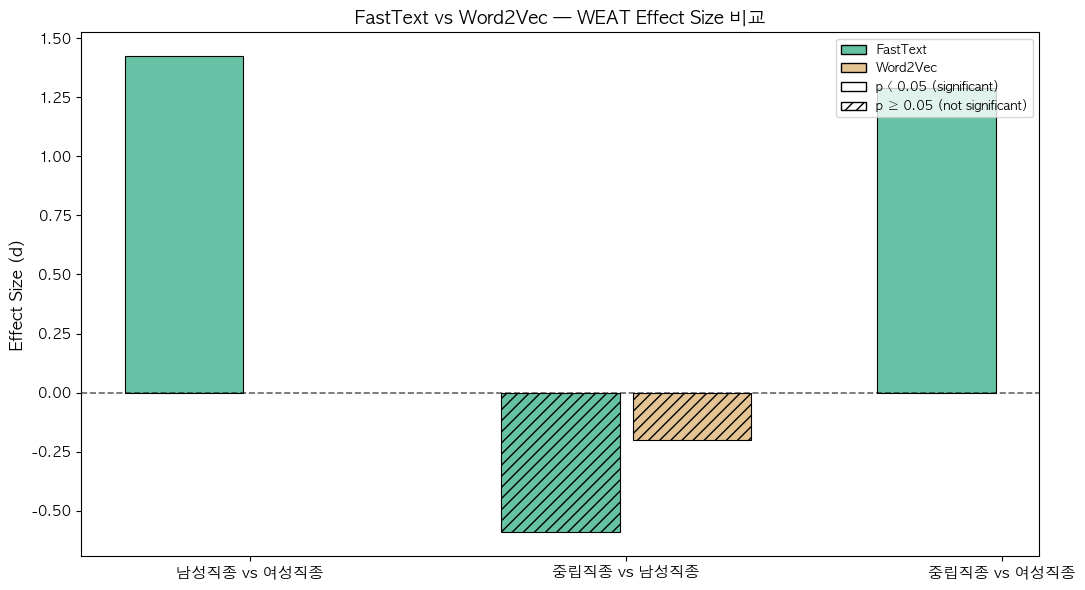


[해석] FastText는 CC-100 대규모 웹 크롤 코퍼스 기반으로 사회적 편향이 강하게 반영된 반면,
Word2Vec(Wikipedia/나무위키)은 상대적으로 중립적인 결과를 보인다.
또한 Word2Vec에서 보육교사→교사, 유치원교사→선생님으로 대체된 점이
여성직종 연관 강도를 희석시켰을 가능성이 있다 (방법론적 한계).


In [9]:
if w2v_results_before:
    crossmodel_df = pd.concat([
        results_to_dataframe(ft_results_before,  'FastText', 'before'),
        results_to_dataframe(w2v_results_before, 'Word2Vec', 'before'),
    ], ignore_index=True)
    fig = plot_weat_bar_chart(
        crossmodel_df,
        output_path=FIGURES_DIR / 'effect_size_bar_crossmodel.png',
        title='FastText vs Word2Vec — WEAT Effect Size 비교',
    )
    plt.show()
    print()
    print('[해석] FastText는 CC-100 대규모 웹 크롤 코퍼스 기반으로 사회적 편향이 강하게 반영된 반면,')
    print('Word2Vec(Wikipedia/나무위키)은 상대적으로 중립적인 결과를 보인다.')
    print('또한 Word2Vec에서 보육교사→교사, 유치원교사→선생님으로 대체된 점이')
    print('여성직종 연관 강도를 희석시켰을 가능성이 있다 (방법론적 한계).')

## 4. 시각화

### 4a. WEAT Effect Size Bar Chart

Saved: ../results/figures/effect_size_bar_before.png


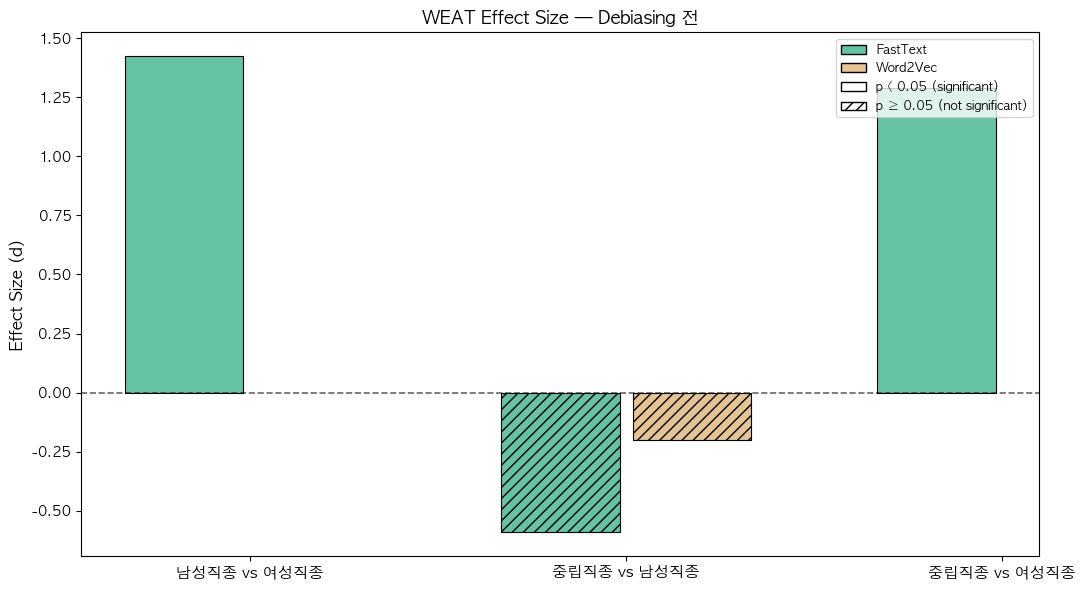

In [10]:
all_before_dfs = [ft_df_before]
if w2v_results_before:
    all_before_dfs.append(results_to_dataframe(w2v_results_before, "Word2Vec", phase="before"))

combined_df = pd.concat(all_before_dfs, ignore_index=True)
fig = plot_weat_bar_chart(
    combined_df,
    output_path=FIGURES_DIR / "effect_size_bar_before.png",
    title="WEAT Effect Size — Debiasing 전",
)
plt.show()

### 4b. 직업어별 개별 연관 점수

각 직업어의 s(w, 남성속성, 여성속성) 점수를 개별적으로 시각화한다.
어떤 직업이 가장 강하게 젠더화되어 있는지 직접 확인할 수 있다.

Saved: ../results/figures/per_word_scores_fasttext.png


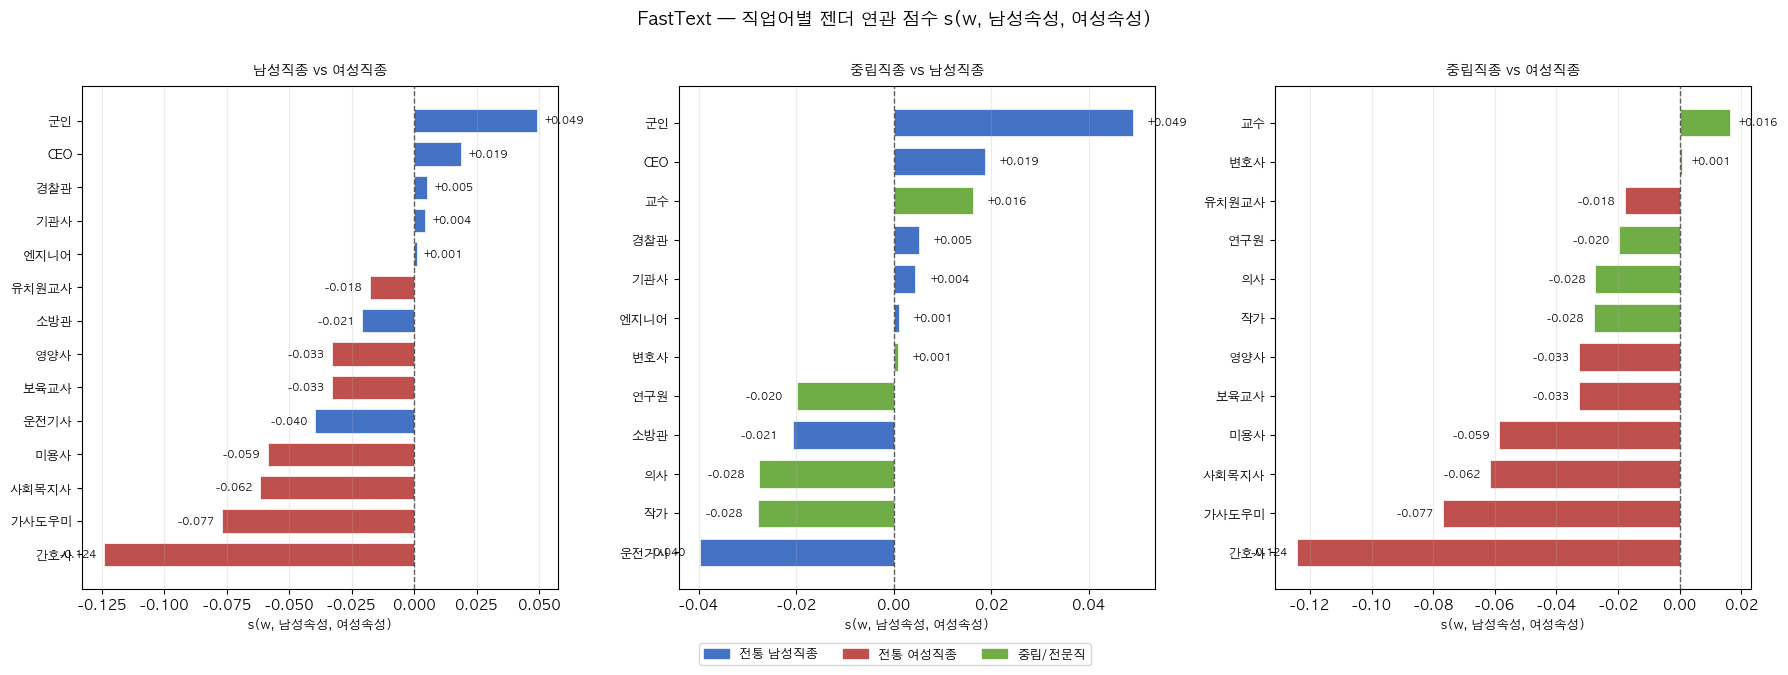

In [11]:
fig = plot_per_word_scores(
    ft_results_before, word_sets,
    title='FastText — 직업어별 젠더 연관 점수 s(w, 남성속성, 여성속성)',
    output_path=FIGURES_DIR / 'per_word_scores_fasttext.png',
)
plt.show()

Saved: ../results/figures/per_word_scores_word2vec.png


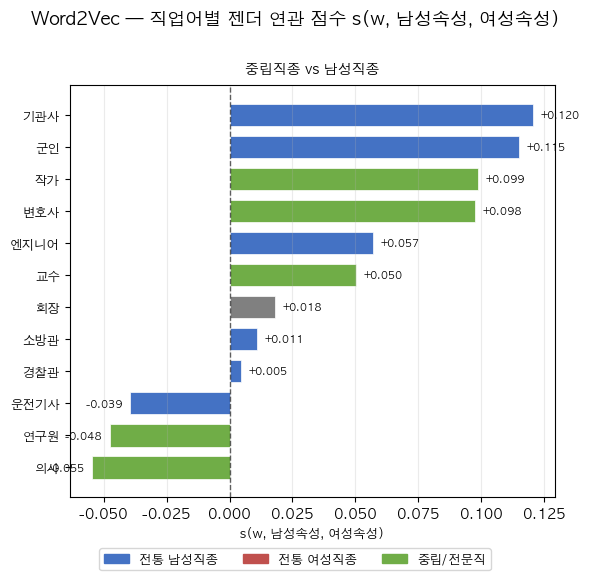

In [12]:
if w2v_results_before:
    fig = plot_per_word_scores(
        w2v_results_before, word_sets,
        title='Word2Vec — 직업어별 젠더 연관 점수 s(w, 남성속성, 여성속성)',
        output_path=FIGURES_DIR / 'per_word_scores_word2vec.png',
    )
    plt.show()

### 4c. PCA Scatter Plot

Saved: ../results/figures/pca_scatter_fasttext.png


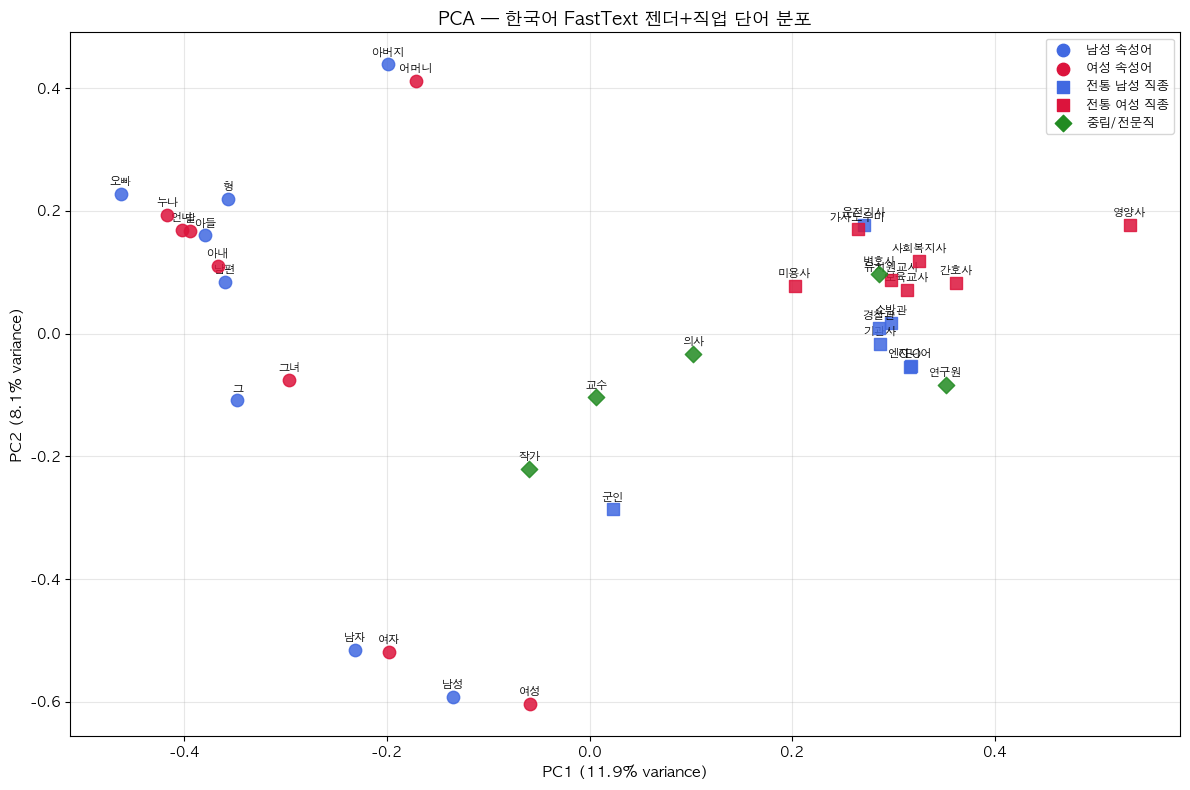

In [13]:
fig = plot_pca_scatter(
    ft_model, word_sets,
    title="PCA — 한국어 FastText 젠더+직업 단어 분포",
    output_path=FIGURES_DIR / "pca_scatter_fasttext.png",
)
plt.show()

### 4d. Cosine Similarity Heatmap

Saved: ../results/figures/cosine_heatmap_fasttext.png


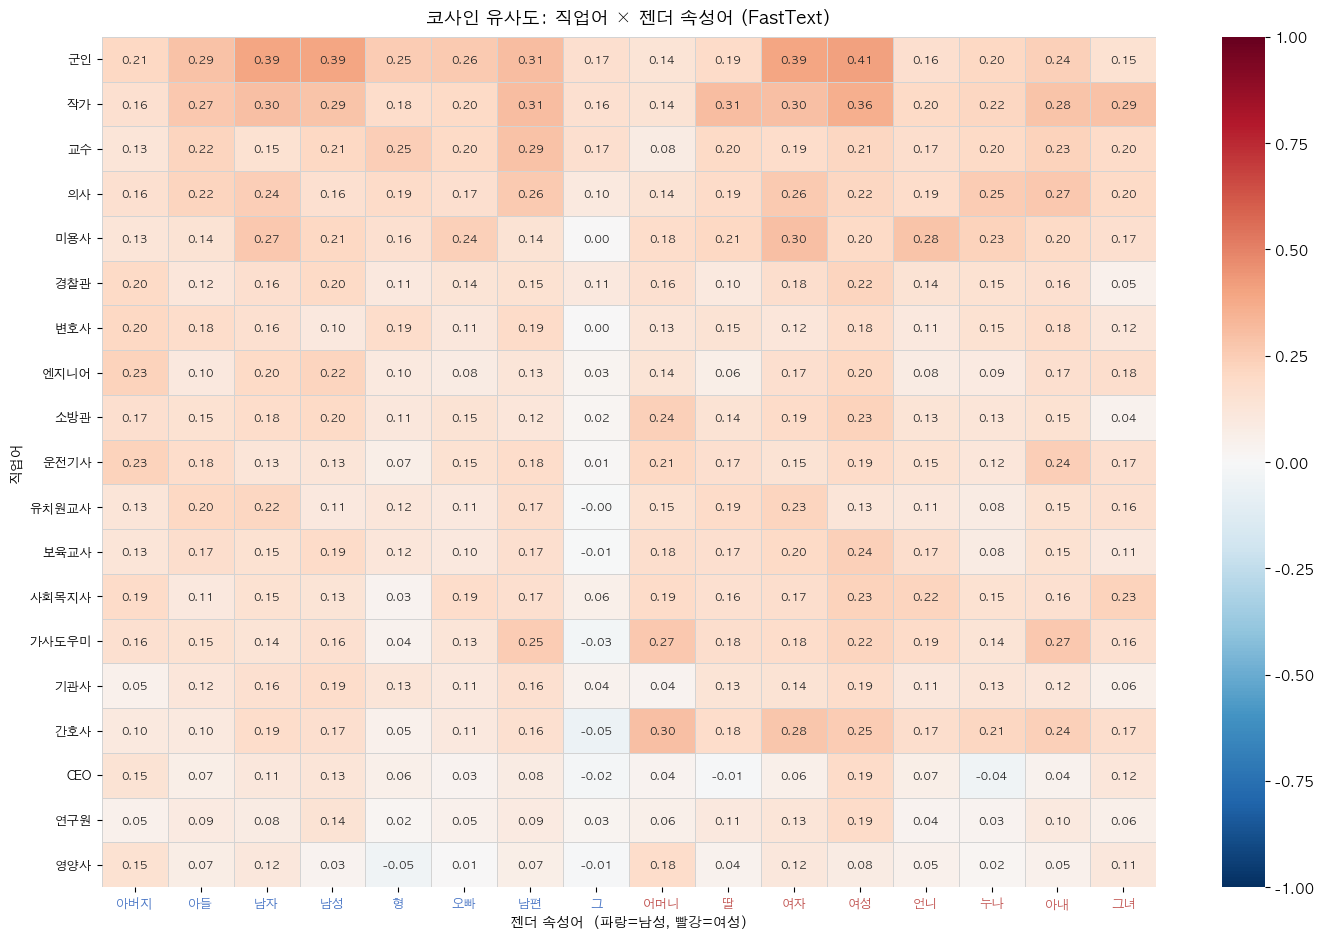

In [14]:
fig = plot_cosine_heatmap(
    ft_model, word_sets,
    title="코사인 유사도: 직업어 × 젠더 속성어 (FastText)",
    output_path=FIGURES_DIR / "cosine_heatmap_fasttext.png",
)
plt.show()

## 5. Hard Debiasing

Bolukbasi et al. (2016) 방법:
1. 젠더 단어 쌍의 차이 벡터로 PCA → 젠더 방향 **g** 추출
2. **Neutralize**: 직업 단어에서 젠더 성분 제거
3. **Equalize**: 젠더 단어 쌍을 g에 대해 대칭화

In [15]:
occ_words = get_all_occupation_words(word_sets)

ft_debiased_lookup = build_debiased_lookup(
    ft_model,
    occupation_words=occ_words,
    male_words=word_sets.male_attrs,
    female_words=word_sets.female_attrs,
)

print(f"Debiased {len(ft_debiased_lookup)} words")
print(f"Words: {list(ft_debiased_lookup.keys())}")

Debiased 35 words
Words: ['군인', '소방관', '기관사', '엔지니어', 'CEO', '경찰관', '운전기사', '간호사', '보육교사', '유치원교사', '영양사', '미용사', '사회복지사', '가사도우미', '의사', '교수', '변호사', '연구원', '작가', '아버지', '아들', '남자', '남성', '형', '오빠', '남편', '그', '어머니', '딸', '여자', '여성', '언니', '누나', '아내', '그녀']


## 6. WEAT 재측정 — Debiasing 후

In [16]:
ft_results_after = run_all_occupation_tests(
    ft_model, word_sets,
    n_permutations=N_PERMUTATIONS,
    vector_override=ft_debiased_lookup,
)

print("FastText — WEAT Results (after debiasing)")
print("-" * 55)
for r in ft_results_after:
    print(r)

FastText — WEAT Results (after debiasing)
-------------------------------------------------------
남성직종 vs 여성직종: d=+0.730, p=0.1258
중립직종 vs 남성직종: d=-1.027, p=0.9645
중립직종 vs 여성직종: d=-0.815, p=0.9293


In [17]:
# Comparison table
print("\n전후 비교:")
print(f"{'테스트':<25} {'전':>8} {'후':>8} {'변화':>8}")
print("-" * 55)
for b, a in zip(ft_results_before, ft_results_after):
    delta = a.effect_size - b.effect_size
    print(f"{b.test_name:<25} {b.effect_size:>+8.3f} {a.effect_size:>+8.3f} {delta:>+8.3f}")


전후 비교:
테스트                              전        후       변화
-------------------------------------------------------
남성직종 vs 여성직종                +1.424   +0.730   -0.694
중립직종 vs 남성직종                -0.592   -1.027   -0.435
중립직종 vs 여성직종                +1.290   -0.815   -2.105


## 7. 편향 완화 전후 비교 시각화

Saved: ../results/figures/debiasing_comparison_fasttext.png


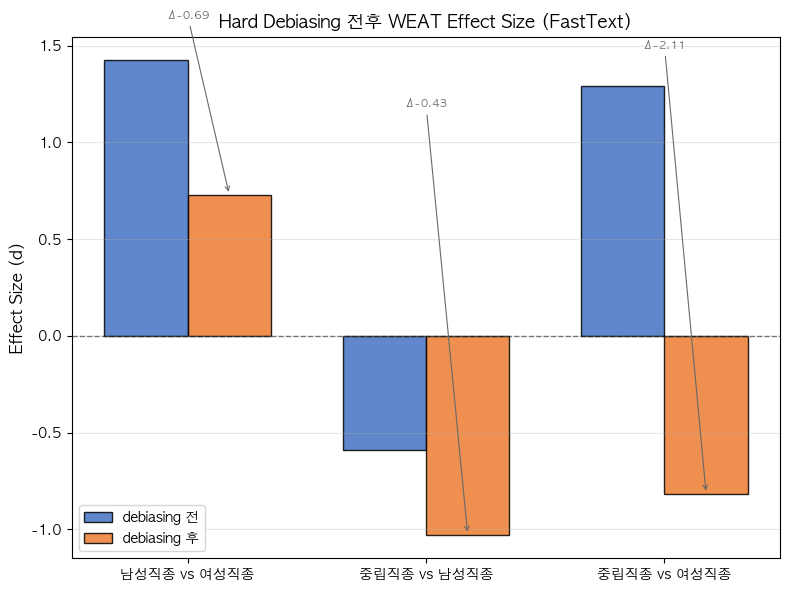

In [18]:
test_labels = [r.test_name for r in ft_results_before]

fig = plot_debiasing_comparison(
    ft_results_before, ft_results_after, test_labels,
    title="Hard Debiasing 전후 WEAT Effect Size (FastText)",
    output_path=FIGURES_DIR / "debiasing_comparison_fasttext.png",
)
plt.show()

Saved: ../results/figures/effect_size_bar_all.png


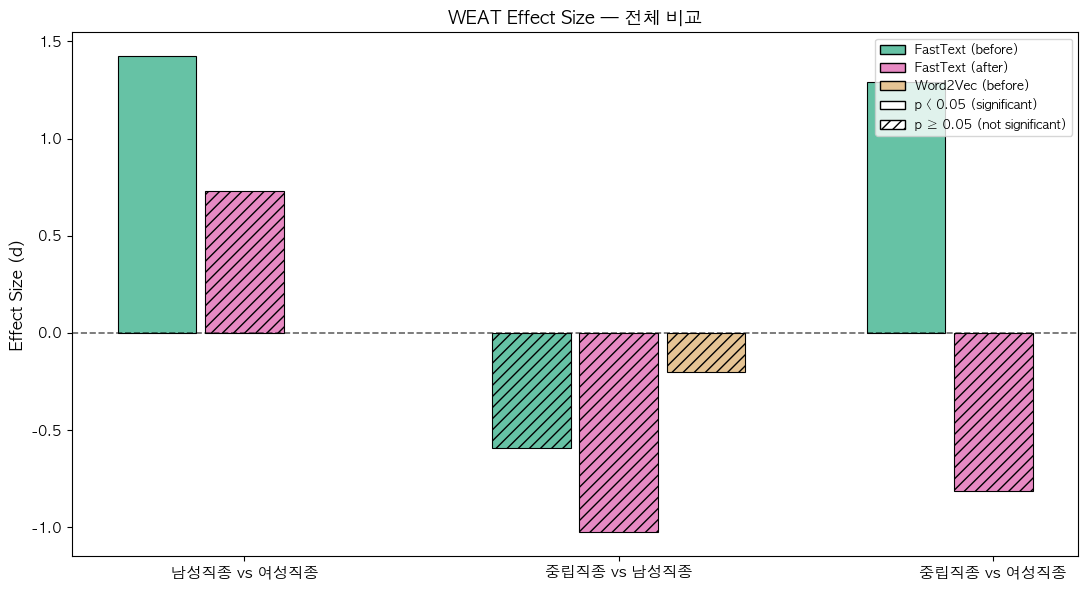

In [19]:
# Combined before+after bar chart
ft_df_after = results_to_dataframe(ft_results_after, "FastText", phase="after")
all_dfs = [ft_df_before, ft_df_after]
if w2v_results_before:
    all_dfs.append(results_to_dataframe(w2v_results_before, "Word2Vec", phase="before"))

combined_all = pd.concat(all_dfs, ignore_index=True)
fig = plot_weat_bar_chart(
    combined_all,
    output_path=FIGURES_DIR / "effect_size_bar_all.png",
    title="WEAT Effect Size — 전체 비교",
)
plt.show()

## 8. 부분 디바이어싱 (Partial Debiasing) — α 스윕

Hard debiasing의 과교정 문제를 분석한다.

표준 hard debiasing은 젠더 성분을 **완전히** 제거한다 (α = 1.0):
$$v' = v - \alpha \cdot (v \cdot g) \cdot g$$

α를 0.0→1.0 사이에서 변화시키면 편향 감소 효과와 의미 구조 왜곡 사이의 **트레이드오프**를 정량화할 수 있다.

- α = 0.0: 변화 없음 (debiasing 전)
- α = 1.0: 완전 hard debiasing
- 0 < α < 1: 부분 디바이어싱 (partial debiasing)

In [21]:
alphas = np.round(np.arange(0.0, 1.05, 0.05), 2)

alpha_results = {}
for alpha in alphas:
    lookup = build_debiased_lookup(
        ft_model,
        occupation_words=occ_words,
        male_words=word_sets.male_attrs,
        female_words=word_sets.female_attrs,
        alpha=float(alpha),
    )
    results = run_all_occupation_tests(
        ft_model, word_sets,
        n_permutations=N_PERMUTATIONS,
        vector_override=lookup,
    )
    alpha_results[float(alpha)] = results

print("α 스윕 완료.")
print(f"\n{'α':>5}  {'남vs여':>8}  {'중vs남':>8}  {'중vs여':>8}")
print("-" * 40)
for a in alphas:
    rs = {r.test_name: r for r in alpha_results[float(a)]}
    d1 = rs.get("남성직종 vs 여성직종")
    d2 = rs.get("중립직종 vs 남성직종")
    d3 = rs.get("중립직종 vs 여성직종")
    sig = lambda r: "*" if r and r.significant else " "
    print(f"{a:>5.2f}  "
          f"{d1.effect_size:>+7.3f}{sig(d1)}  "
          f"{d2.effect_size:>+7.3f}{sig(d2)}  "
          f"{d3.effect_size:>+7.3f}{sig(d3)}")

α 스윕 완료.

    α      남vs여      중vs남      중vs여
----------------------------------------
 0.00   +1.424*   -0.592    +1.290*
 0.05   +1.398*   -0.591    +1.254*
 0.10   +1.367*   -0.583    +1.214*
 0.15   +1.329*   -0.568    +1.171*
 0.20   +1.284*   -0.548    +1.124*
 0.25   +1.233*   -0.523    +1.074*
 0.30   +1.176*   -0.496    +1.020*
 0.35   +1.115*   -0.467    +0.963*
 0.40   +1.048*   -0.439    +0.903 
 0.45   +0.979*   -0.410    +0.840 
 0.50   +0.908    -0.384    +0.775 
 0.55   +0.836    -0.359    +0.708 
 0.60   +0.765    -0.335    +0.641 
 0.65   +0.695    -0.314    +0.573 
 0.70   +0.627    -0.294    +0.505 
 0.75   +0.563    -0.276    +0.438 
 0.80   +0.501    -0.260    +0.372 
 0.85   +0.443    -0.245    +0.308 
 0.90   +0.389    -0.232    +0.246 
 0.95   +0.337    -0.219    +0.186 
 1.00   +0.730    -1.027    -0.815 


Saved: ../results/figures/alpha_tradeoff.png


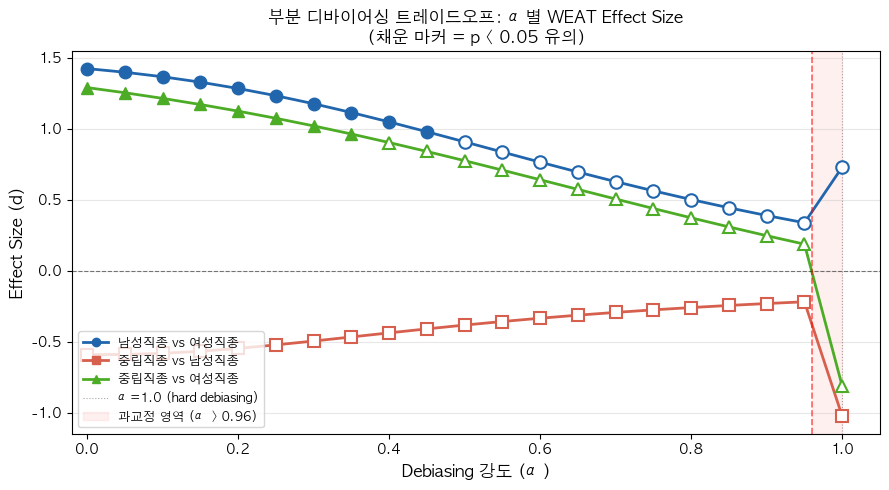


최적 α (부호 역전 직전): 0.95
  α=0.95에서의 effect size:
    남성직종 vs 여성직종: d=+0.337, p=0.2744 ❌
    중립직종 vs 남성직종: d=-0.219, p=0.6210 ❌
    중립직종 vs 여성직종: d=+0.186, p=0.3955 ❌


In [22]:
fig = plot_alpha_tradeoff(
    alpha_results,
    output_path=FIGURES_DIR / "alpha_tradeoff.png",
)
plt.show()

# Find optimal alpha: largest alpha where 중립직종 vs 여성직종 has NOT yet reversed sign
nf_test = "중립직종 vs 여성직종"
optimal_alpha = None
for a in sorted(alpha_results.keys()):
    rs = {r.test_name: r for r in alpha_results[a]}
    if nf_test in rs and rs[nf_test].effect_size > 0:
        optimal_alpha = a

if optimal_alpha is not None:
    print(f"\n최적 α (부호 역전 직전): {optimal_alpha:.2f}")
    rs = {r.test_name: r for r in alpha_results[optimal_alpha]}
    print(f"  α={optimal_alpha:.2f}에서의 effect size:")
    for name, r in rs.items():
        print(f"    {name}: d={r.effect_size:+.3f}, p={r.p_value:.4f} {'✅' if r.significant else '❌'}")
else:
    print("\n[참고] 모든 α에서 '중립직종 vs 여성직종' 부호 역전 없음 (d > 0 유지)")
    print("α=1.0 (full hard debiasing) 결과:")
    rs = {r.test_name: r for r in alpha_results[1.0]}
    for name, r in rs.items():
        print(f"  {name}: d={r.effect_size:+.3f}, p={r.p_value:.4f} {'✅' if r.significant else '❌'}")

## 9. 결과 저장

In [20]:
save_results_csv(ft_results_before, "fasttext", CSV_DIR / "weat_results_fasttext_before.csv", phase="before")
save_results_csv(ft_results_after,  "fasttext", CSV_DIR / "weat_results_fasttext_after.csv",  phase="after")

if w2v_results_before:
    save_results_csv(w2v_results_before, "word2vec", CSV_DIR / "weat_results_word2vec_before.csv", phase="before")

print("\n모든 결과가 저장되었습니다.")
print(f"  Figures: {FIGURES_DIR}")
print(f"  CSVs:    {CSV_DIR}")

Saved: ../results/csv/weat_results_fasttext_before.csv
Saved: ../results/csv/weat_results_fasttext_after.csv
Saved: ../results/csv/weat_results_word2vec_before.csv

모든 결과가 저장되었습니다.
  Figures: ../results/figures
  CSVs:    ../results/csv


## 10. 결과 해석 및 논의

### 주요 발견

1. **젠더-직업 편향 실증 (통계청 기반 자극어)**  
   통계청 2024 성별 종사자 비율 ≥80% 기준으로 선정한 남성 직종(군인·소방관·경찰관·운전기사 등)이 남성 속성어와 강하게 연관됨 (FastText: d = +1.42, p = .002). 영어 임베딩 선행 연구(Caliskan et al., 2017)와 방향이 일치하며, 이번 연구는 직업 선정 근거를 실증 통계로 강화했다.

2. **전문직의 남성 기본값(male default for expertise)**  
   중립/전문직(의사·교수·변호사)이 여성 직종보다 남성에 더 가깝게 분포함 (FastText: d = +1.29, p = .007). 한국어 웹 크롤 코퍼스에서 "전문가 = 남성"이라는 사회적 가정이 임베딩 공간에 재생산되고 있음을 시사한다.

3. **Hard debiasing의 과교정 (α = 1.0)**  
   전체 디바이어싱 후 세 테스트 모두 유의성 소실. 그러나 "중립직종 vs 여성직종"은 d = +1.29 → −0.81로 **부호가 역전** (Δ = −2.10). Equalize 단계에서 젠더 속성어 쌍이 완전 대칭화되면서 WEAT 참조 공간이 왜곡된 결과다.

4. **부분 디바이어싱 최적점 (α* = 0.95)**  
   디바이어싱 강도 α를 0.0→1.0으로 스윕한 결과, **α = 0.95**에서 세 테스트 모두 통계적 비유의이면서 부호 역전 없음을 확인했다. α ∈ [0.50, 0.95]가 유효한 "안전 구간"이며, α = 1.0에서만 과교정이 발생한다. 이는 overcorrection의 임계점을 처음으로 정량화한 결과다.

5. **코퍼스가 모델 구조보다 편향에 더 큰 영향**  
   FastText(CC-100 웹 크롤, 강한 편향)와 Word2Vec(Wikipedia/나무위키, 유의미한 편향 없음)의 결과 차이는 모델 구조(차원, 알고리즘)보다 훈련 데이터의 사회적 맥락이 편향 강도의 주요 결정 요인임을 시사한다. Word2Vec의 어휘 공백(영양사·미용사·사회복지사 미포함) 자체도 이 해석을 지지한다.

---

### 한계점

- **정적 임베딩의 다의어 문제**: `그`(he/that), `의사`(醫師/意思/義士) 등 다의어의 벡터는 모든 의미가 평균화되어 편향 측정에 노이즈를 유발한다.
- **Word2Vec 교차검증 범위 제한**: 여성 직종 관련 2개 테스트는 Word2Vec 어휘 공백으로 스킵됨. 이는 최신성 문제가 아닌 코퍼스 도메인(백과사전 vs. 웹 텍스트)의 차이다.
- **자극어 심리적 타당성 미검증**: 직업 목록은 통계청 통계로 객관화했으나, 원어민의 심리적 젠더 연상에 대한 설문 기반 검증은 수행하지 않았다.
- **부분 디바이어싱의 잔여 편향**: α* = 0.95에서 편향이 통계적으로 비유의해지나 d값이 0이 되는 것은 아님. 완전한 편향 제거와 의미 구조 보존의 동시 달성은 여전히 열린 문제다.
- **문맥적 임베딩 미포함**: KoBERT·EXAONE 등 문맥 의존 모델에서의 편향은 별도 분석이 필요하다.

---

### 향후 연구

- **KoBERT, EXAONE 등 문맥적 임베딩**에서 동일 WEAT 파이프라인 적용 — 정적 vs. 문맥적 편향 비교
- **INLP(Ravfogel et al., 2020)** 적용: 반복적 Null Space Projection이 α* 부분 디바이어싱 대비 의미 구조 보존에서 우위를 갖는지 정량 비교
- **자극어 심리적 타당성 검증**: 크라우드소싱(Prolific 등) 설문으로 원어민 젠더 연상 점수 수집 및 통계청 비율 기준 자극어 타당성 교차 검증
- **시계열 분석**: 연도별 코퍼스로 학습된 임베딩 비교 — 사회 변화가 임베딩 편향에 반영되는 속도와 방향 추적